# Projekat 3 — Veštačke neuronske mreže za klasifikaciju vremenskih uslova

Marija Cvetković 1940 \
Luka Kocić 2022

**Dataset:** [Weather Classification Data](https://www.kaggle.com/datasets/nikhil7280/weather-type-classification) — 13,200 uzoraka sa 11 kolona, klasifikacija po `Weather Type` (Cloudy, Rainy, Snowy, Sunny).

**Fičeri:**
- `Temperature`: Temperatura vazduha
- `Humidity`: Vlažnost vazduha
- `Wind Speed`: Brzina vetra
- `Precipitation (%)`: Procenat padavina
- `Cloud Cover`: Oblačnost (kategorička)
- `Atmospheric Pressure`: Atmosferski pritisak
- `UV Index`: UV indeks
- `Season`: Godišnje doba (kategorička)
- `Visibility (km)`: Vidljivost izražena u kilometrima
- `Location`: Lokacija (kategorička)
- `Weather Type`: Tip vremena — ciljna klasa za predviđanje (Cloudy, Rainy, Snowy, Sunny)

## 1. Učitavanje podataka

In [1]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score, ConfusionMatrixDisplay
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
import os
import random
import numpy as np
import tensorflow as tf
import keras

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
keras.utils.set_random_seed(SEED)

tf.config.experimental.enable_op_determinism()

In [2]:
df = pd.read_csv('weather_classification_data.csv')
print(f"Dimenzije dataseta: {df.shape}")
df.head(10)

Dimenzije dataseta: (13200, 11)


,Temperature,Humidity,Wind Speed,Precipitation (%),Cloud Cover,Atmospheric Pressure,UV Index,Season,Visibility (km),Location,Weather Type
0,14.0,73,9.5,82.0,partly cloudy,1010.82,2,Winter,3.5,inland,Rainy
1,39.0,96,8.5,71.0,partly cloudy,1011.43,7,Spring,10.0,inland,Cloudy
2,30.0,64,7.0,16.0,clear,1018.72,5,Spring,5.5,mountain,Sunny
3,38.0,83,1.5,82.0,clear,1026.25,7,Spring,1.0,coastal,Sunny
4,27.0,74,17.0,66.0,overcast,990.67,1,Winter,2.5,mountain,Rainy
5,32.0,55,3.5,26.0,overcast,1010.03,2,Summer,5.0,inland,Cloudy
6,-2.0,97,8.0,86.0,overcast,990.87,1,Winter,4.0,inland,Snowy
7,3.0,85,6.0,96.0,partly cloudy,984.46,1,Winter,3.5,inland,Snowy
8,3.0,83,6.0,66.0,overcast,999.44,0,Winter,1.0,mountain,Snowy
9,28.0,74,8.5,107.0,clear,1012.13,8,Winter,7.5,coastal,Sunny


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 13200 entries, 0 to 13199
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Temperature           13200 non-null  float64
 1   Humidity              13200 non-null  int64  
 2   Wind Speed            13200 non-null  float64
 3   Precipitation (%)     13200 non-null  float64
 4   Cloud Cover           13200 non-null  str    
 5   Atmospheric Pressure  13200 non-null  float64
 6   UV Index              13200 non-null  int64  
 7   Season                13200 non-null  str    
 8   Visibility (km)       13200 non-null  float64
 9   Location              13200 non-null  str    
 10  Weather Type          13200 non-null  str    
dtypes: float64(5), int64(2), str(4)
memory usage: 1.1 MB


In [4]:
df.describe().round(2)

,Temperature,Humidity,Wind Speed,Precipitation (%),Atmospheric Pressure,UV Index,Visibility (km)
count,13200.00,13200.00,13200.00,13200.00,13200.00,13200.00,13200.00
mean,19.13,68.71,9.83,53.64,1005.83,4.01,5.46
std,17.39,20.19,6.91,31.95,37.20,3.86,3.37
min,-25.00,20.00,0.00,0.00,800.12,0.00,0.00
25%,4.00,57.00,5.00,19.00,994.80,1.00,3.00
50%,21.00,70.00,9.00,58.00,1007.65,3.00,5.00
75%,31.00,84.00,13.50,82.00,1016.77,7.00,7.50
max,109.00,109.00,48.50,109.00,1199.21,14.00,20.00


In [5]:
print("Nedostajuće vrednosti po koloni:")
print(df.isnull().sum())
print(f"\nUkupno nedostajućih: {df.isnull().sum().sum()}")

Nedostajuće vrednosti po koloni:
Temperature             0
Humidity                0
Wind Speed              0
Precipitation (%)       0
Cloud Cover             0
Atmospheric Pressure    0
UV Index                0
Season                  0
Visibility (km)         0
Location                0
Weather Type            0
dtype: int64

Ukupno nedostajućih: 0


## 2. Deskriptivna analiza i vizuelizacija

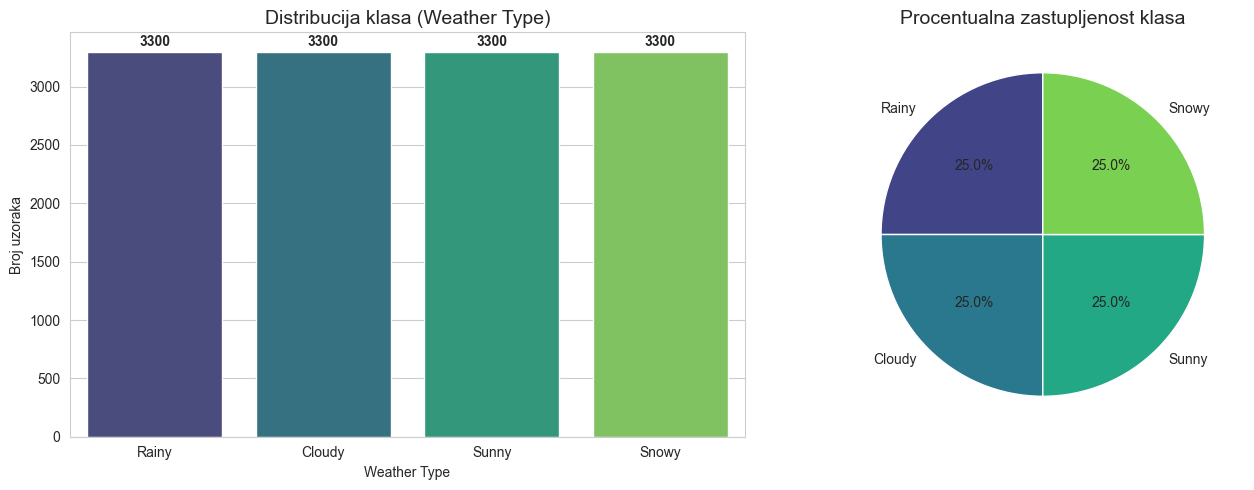

In [6]:
# Distribucija ciljne promenljive
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot
class_counts = df['Weather Type'].value_counts()
sns.barplot(x=class_counts.index, y=class_counts.values, ax=axes[0], palette='viridis')
axes[0].set_title('Distribucija klasa (Weather Type)', fontsize=14)
axes[0].set_ylabel('Broj uzoraka')
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(class_counts.values, labels=class_counts.index, autopct='%1.1f%%',
            colors=sns.color_palette('viridis', 4), startangle=90)
axes[1].set_title('Procentualna zastupljenost klasa', fontsize=14)

plt.tight_layout()
plt.show()

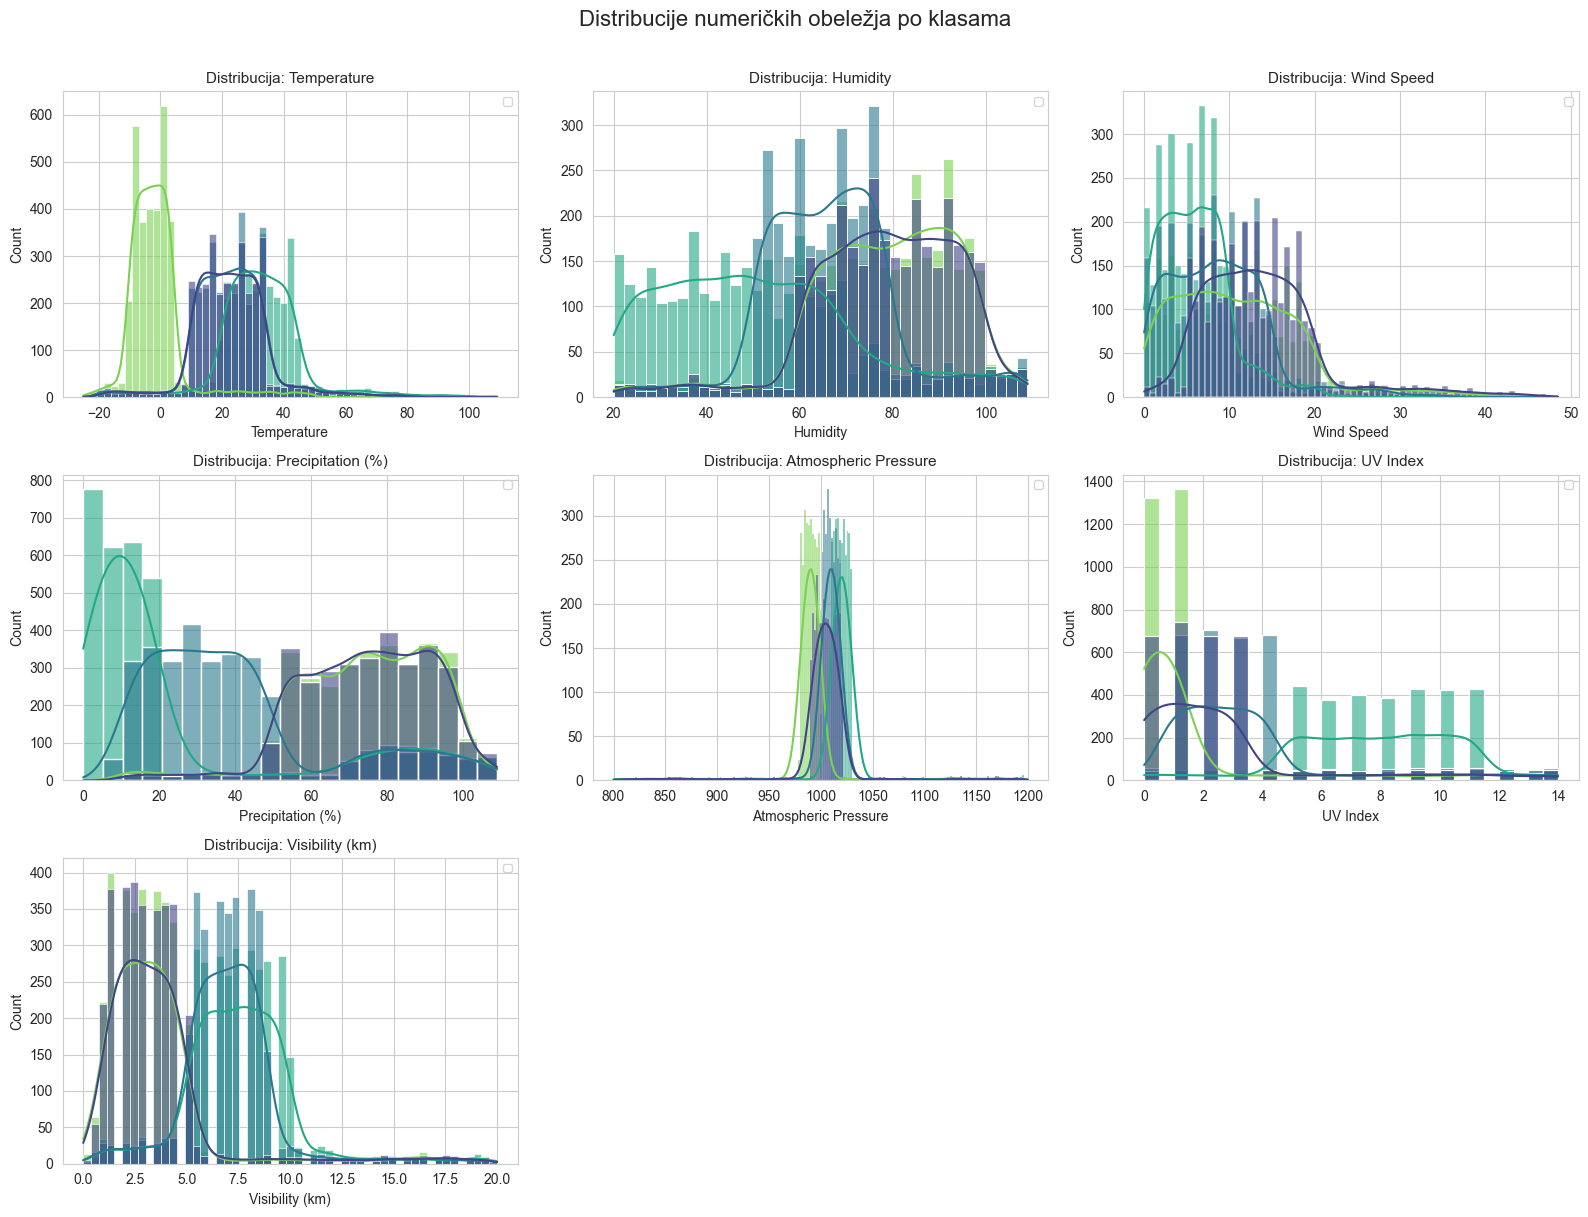

In [7]:
numerical_cols = ['Temperature', 'Humidity', 'Wind Speed', 'Precipitation (%)',
                  'Atmospheric Pressure', 'UV Index', 'Visibility (km)']

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.histplot(data=df, x=col, hue='Weather Type', kde=True, ax=axes[i],
                 palette='viridis', alpha=0.6)
    axes[i].set_title(f'Distribucija: {col}', fontsize=11)
    axes[i].legend(fontsize=8)

for j in range(len(numerical_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribucije numeričkih obeležja po klasama', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

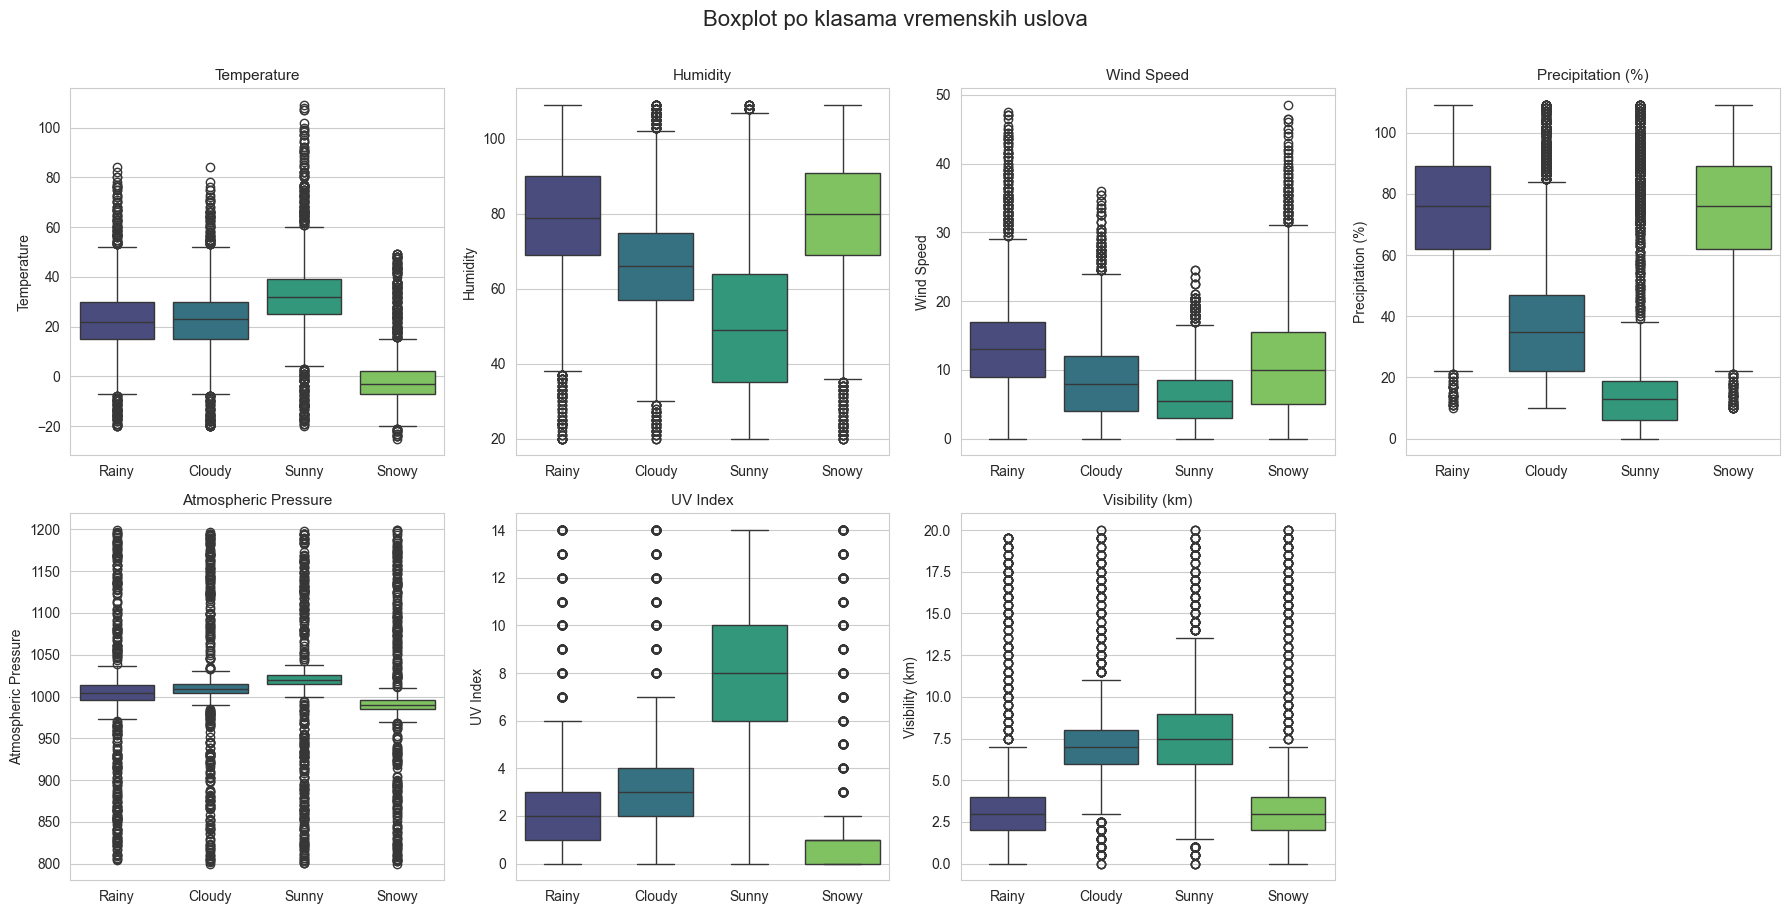

In [8]:
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.boxplot(data=df, x='Weather Type', y=col, ax=axes[i], palette='viridis')
    axes[i].set_title(f'{col}', fontsize=11)
    axes[i].set_xlabel('')

axes[-1].set_visible(False)
plt.suptitle('Boxplot po klasama vremenskih uslova', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

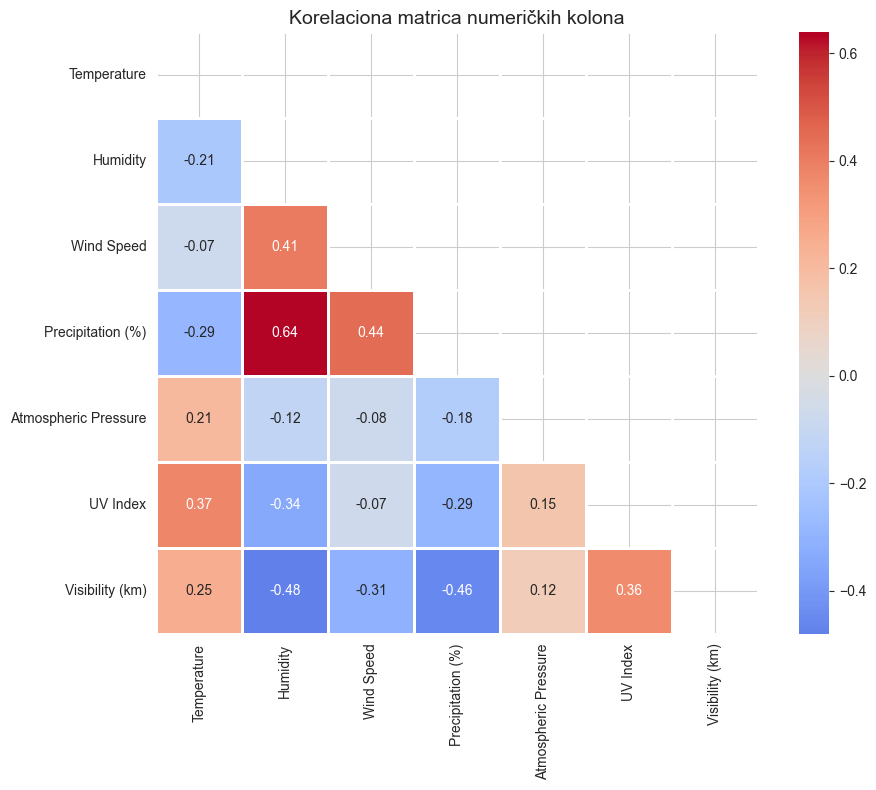

In [9]:
plt.figure(figsize=(10, 8))
corr_matrix = df[numerical_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=1)
plt.title('Korelaciona matrica numeričkih kolona', fontsize=14)
plt.tight_layout()
plt.show()

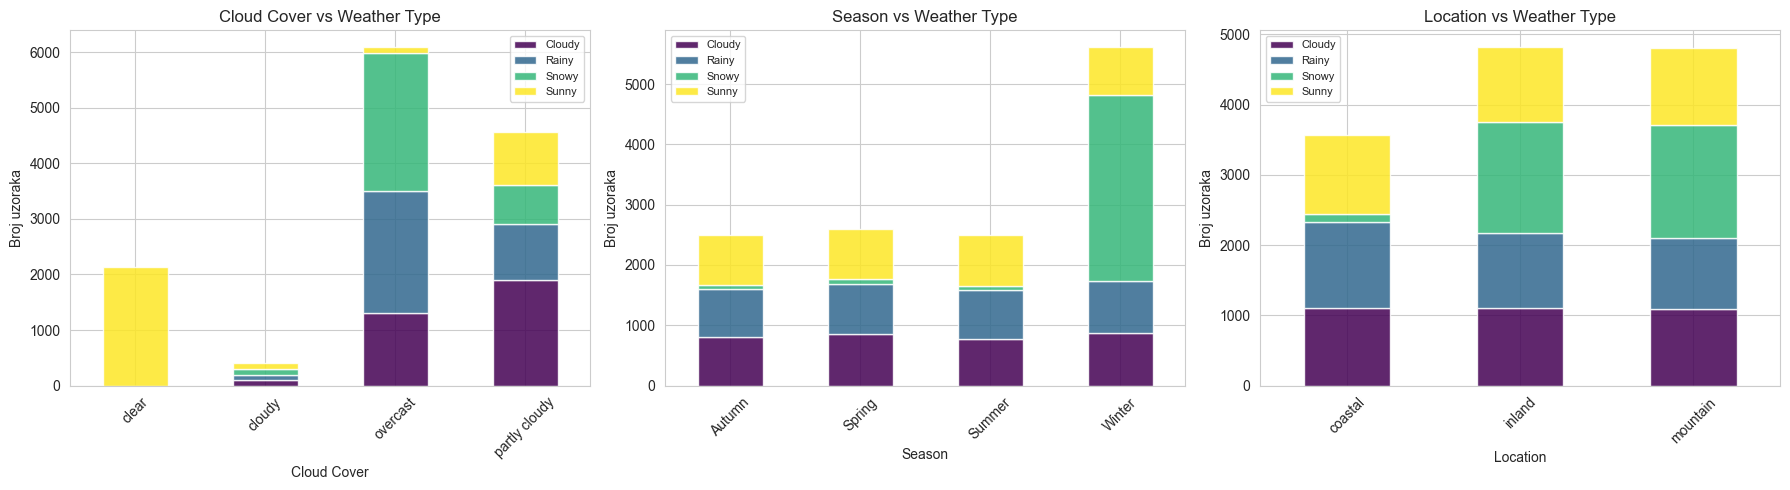

In [10]:
cat_cols = ['Cloud Cover', 'Season', 'Location']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, col in enumerate(cat_cols):
    ct = pd.crosstab(df[col], df['Weather Type'])
    ct.plot(kind='bar', stacked=True, ax=axes[i], colormap='viridis', alpha=0.85)
    axes[i].set_title(f'{col} vs Weather Type', fontsize=12)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Broj uzoraka')
    axes[i].legend(fontsize=8)
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 3. Priprema podataka

1. **Label Encoding** kategoričkih obeležja (`Cloud Cover`, `Season`, `Location`)
2. **Standardizacija** (StandardScaler) numeričkih obeležja, neuronske mreže su osetljive na skalu podataka
3. **Podela** na trening (70%), validacioni (15%) i test (15%) skup
4. **One-hot encoding** ciljne promenljive za Keras model

In [11]:
from sklearn.preprocessing import LabelEncoder

# One-hot encoding za ulazne kategorijske kolone
df = pd.get_dummies(df, columns=['Cloud Cover', 'Season', 'Location'])

# Label encoding samo za target promenljivu
label_encoder_target = LabelEncoder()
df['Weather Type'] = label_encoder_target.fit_transform(df['Weather Type'])

class_names = label_encoder_target.classes_
n_classes = len(class_names)

print(f"\nCiljne klase: {dict(zip(class_names, label_encoder_target.transform(class_names)))}")
print(f"Broj klasa: {n_classes}")

# Feature matrica i target vektor
X = df.drop(columns=['Weather Type']).values
y = df['Weather Type'].values

print(f"Ulazna dimenzija: {X.shape}")
print(f"Izlazna dimenzija: {y.shape}")

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.176, random_state=42, stratify=y_train_val
)

print(f"\nTrening skup:      {X_train.shape[0]} uzoraka ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Validacioni skup:  {X_val.shape[0]} uzoraka ({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"Test skup:         {X_test.shape[0]} uzoraka ({X_test.shape[0]/len(X)*100:.1f}%)")


Ciljne klase: {'Cloudy': np.int64(0), 'Rainy': np.int64(1), 'Snowy': np.int64(2), 'Sunny': np.int64(3)}
Broj klasa: 4
Ulazna dimenzija: (13200, 18)
Izlazna dimenzija: (13200,)

Trening skup:      9245 uzoraka (70.0%)
Validacioni skup:  1975 uzoraka (15.0%)
Test skup:         1980 uzoraka (15.0%)


In [12]:
# Standardizacija obeležja
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

print("Srednje vrednosti trening skupa nakon skaliranja (≈0):")
print(np.round(X_train.mean(axis=0), 4))
print("\nStandardne devijacije trening skupa nakon skaliranja (≈1):")
print(np.round(X_train.std(axis=0), 4))

Srednje vrednosti trening skupa nakon skaliranja (≈0):
[ 0.  0.  0.  0.  0.  0. -0.  0. -0.  0. -0.  0. -0. -0.  0.  0.  0.  0.]

Standardne devijacije trening skupa nakon skaliranja (≈1):
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [13]:
# One-hot encoding ciljne promenljive za Keras
y_train_cat = to_categorical(y_train, num_classes=n_classes)
y_val_cat = to_categorical(y_val, num_classes=n_classes)
y_test_cat = to_categorical(y_test, num_classes=n_classes)

print(f"One-hot shape (trening): {y_train_cat.shape}")
print(f"Primer: klasa {y_train[0]} → {y_train_cat[0]}")

One-hot shape (trening): (9245, 4)
Primer: klasa 3 → [0. 0. 0. 1.]


## 4. Model 1 — MLPClassifier (scikit-learn)

`MLPClassifier` iz scikit-learn biblioteke sa:
- **Arhitektura:** 3 skrivena sloja (128, 64, 32 neurona)
- **Aktivaciona funkcija:** ReLU
- **Optimizator:** Adam
- **Regularizacija:** L2 (alpha=0.001)
- **Maks. iteracija:** 300 epoha

In [ ]:
# Kreiranje i treniranje MLPClassifier modela
mlp_sklearn = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32),
    activation='relu',
    solver='adam',
    alpha=0.001,
    batch_size=64,
    max_iter=300,
    early_stopping=True,
    validation_fraction=0.15,
    n_iter_no_change=15,
    random_state=42,
    verbose=True,
    shuffle=False
)

mlp_sklearn.fit(X_train, y_train)
print(f"\nBroj iteracija: {mlp_sklearn.n_iter_}")
print(f"Krajnji loss: {mlp_sklearn.loss_:.4f}")

Iteration 1, loss = 0.64958145
Validation score: 0.902668
Iteration 2, loss = 0.29980547
Validation score: 0.905552
Iteration 3, loss = 0.25240457
Validation score: 0.909877
Iteration 4, loss = 0.22699979
Validation score: 0.912040
Iteration 5, loss = 0.20959725
Validation score: 0.911319
Iteration 6, loss = 0.19619329
Validation score: 0.917808
Iteration 7, loss = 0.19009725
Validation score: 0.906994
Iteration 8, loss = 0.18376292
Validation score: 0.913482
Iteration 9, loss = 0.17242230
Validation score: 0.908435
Iteration 10, loss = 0.16896972
Validation score: 0.912040
Iteration 11, loss = 0.16245566
Validation score: 0.917808
Iteration 12, loss = 0.15777653
Validation score: 0.909156
Iteration 13, loss = 0.15153524
Validation score: 0.909877
Iteration 14, loss = 0.14658856
Validation score: 0.911319
Iteration 15, loss = 0.14094556
Validation score: 0.902668
Iteration 16, loss = 0.13847940
Validation score: 0.914203
Iteration 17, loss = 0.13384929
Validation score: 0.913482
Iterat

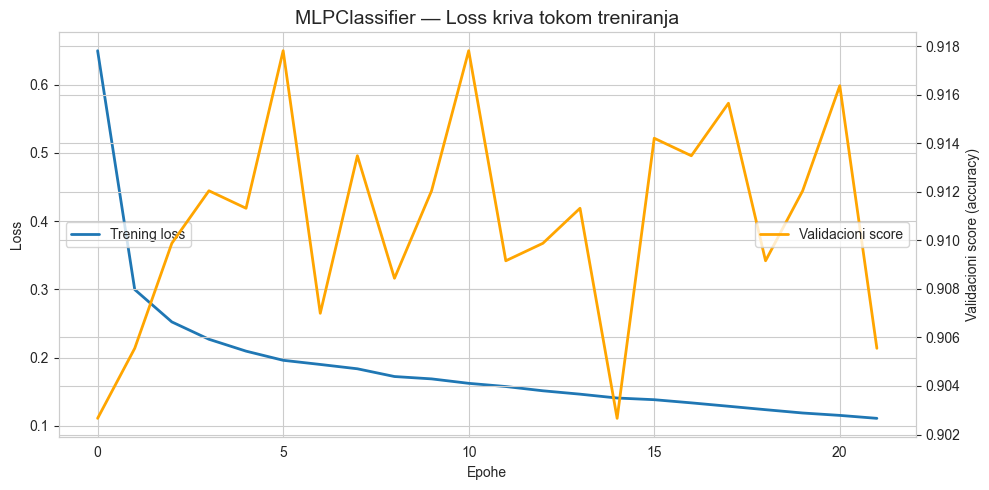

In [15]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(mlp_sklearn.loss_curve_, label='Trening loss', linewidth=2)
if hasattr(mlp_sklearn, 'validation_scores_'):
    ax2 = ax.twinx()
    ax2.plot(mlp_sklearn.validation_scores_, label='Validacioni score', color='orange', linewidth=2)
    ax2.set_ylabel('Validacioni score (accuracy)')
    ax2.legend(loc='center right')
ax.set_xlabel('Epohe')
ax.set_ylabel('Loss')
ax.set_title('MLPClassifier — Loss kriva tokom treniranja', fontsize=14)
ax.legend(loc='center left')
plt.tight_layout()
plt.show()

MLPClassifier (scikit-learn) — Rezultati na test skupu

Tačnost (Accuracy): 0.9045

Klasifikacioni izveštaj:
              precision    recall  f1-score   support

      Cloudy       0.85      0.90      0.88       495
       Rainy       0.90      0.91      0.91       495
       Snowy       0.97      0.89      0.93       495
       Sunny       0.90      0.91      0.90       495

    accuracy                           0.90      1980
   macro avg       0.91      0.90      0.91      1980
weighted avg       0.91      0.90      0.91      1980



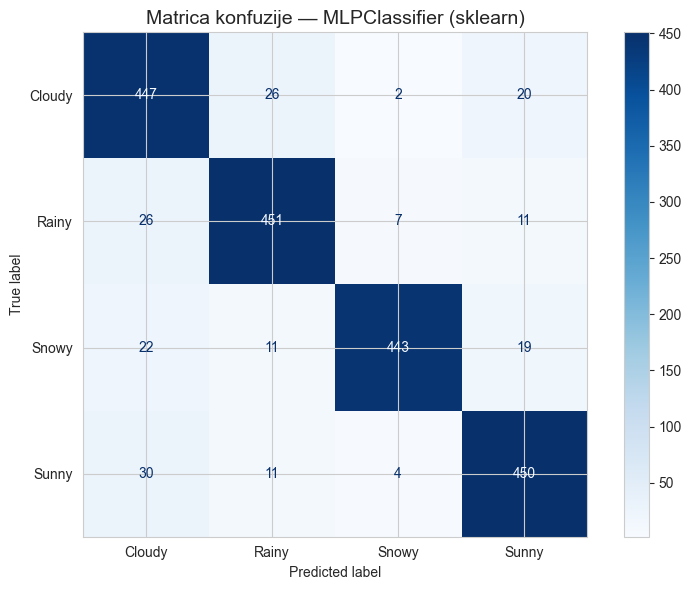

In [16]:
y_pred_sklearn = mlp_sklearn.predict(X_test)

print("MLPClassifier (scikit-learn) — Rezultati na test skupu")
print(f"\nTačnost (Accuracy): {accuracy_score(y_test, y_pred_sklearn):.4f}")
print(f"\nKlasifikacioni izveštaj:")
print(classification_report(y_test, y_pred_sklearn, target_names=class_names))

# Matrica konfuzije
fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_sklearn)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, cmap='Blues', values_format='d')
ax.set_title('Matrica konfuzije — MLPClassifier (sklearn)', fontsize=14)
plt.tight_layout()
plt.show()

## 5. Model 2 — Keras Sequential neuronska mreža (TensorFlow)

Keras model sa sledećom arhitekturom:
- **Ulazni sloj:** 10 obeležja
- **Skriveni sloj 1:** 128 neurona, ReLU, BatchNormalization, Dropout(0.3)
- **Skriveni sloj 2:** 64 neurona, ReLU, BatchNormalization, Dropout(0.3)
- **Skriveni sloj 3:** 32 neurona, ReLU, BatchNormalization, Dropout(0.2)
- **Izlazni sloj:** 4 neurona (softmax) — za 4 klase

**Loss funkcija:** Categorical Crossentropy (standardna loss funkcija za multi-class klasifikaciju).

**Optimizator:** Adam sa learning rate = 0.001

**Callback:** EarlyStopping — zaustavlja treniranje kada se validacioni loss ne poboljšava 15 epoha.

## Loss funkcija 


In [17]:
import tensorflow as tf

def custom_categorical_crossentropy(y_true, y_pred):
    label_smoothing = 0.1
    
    num_classes = tf.cast(tf.shape(y_true)[-1], tf.float32)
    y_true_smooth = y_true * (1.0 - label_smoothing) + (label_smoothing / num_classes)
    
    y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
    
    loss = -tf.reduce_sum(y_true_smooth * tf.math.log(y_pred), axis=1)
    return tf.reduce_mean(loss)

In [18]:
n_features = X_train.shape[1]

keras_model = Sequential([
    # Skriveni sloj 1
    Dense(128, activation='relu', input_shape=(n_features,)),
    BatchNormalization(),
    Dropout(0.3),

    # Skriveni sloj 2
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    # Skriveni sloj 3
    Dense(32, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),

    # Izlazni sloj — softmax za multi-class klasifikaciju
    Dense(n_classes, activation='softmax')
])

keras_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=['accuracy']
)

keras_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,796 (53.89 KB)

 Trainable params: 13,348 (52.14 KB)

 Non-trainable params: 448 (1.75 KB)

In [19]:
# Treniranje Keras modela
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

history = keras_model.fit(
    X_train, y_train_cat,
    epochs=150,
    batch_size=64,
    validation_data=(X_val, y_val_cat),
    callbacks=[early_stop],
    verbose=1,
    shuffle=False
)

print(f"\nTreniranje završeno nakon {len(history.history['loss'])} epoha.")

Epoch 1/150
145/145 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7025 - loss: 0.8215 - val_accuracy: 0.8739 - val_loss: 0.4578
Epoch 2/150
145/145 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8469 - loss: 0.4521 - val_accuracy: 0.8866 - val_loss: 0.3185
Epoch 3/150
145/145 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8671 - loss: 0.3800 - val_accuracy: 0.8927 - val_loss: 0.2865
Epoch 4/150
145/145 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8819 - loss: 0.3440 - val_accuracy: 0.8906 - val_loss: 0.2720
Epoch 5/150
145/145 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8832 - loss: 0.3185 - val_accuracy: 0.8987 - val_loss: 0.2639
Epoch 6/150
145/145 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8892 - loss: 0.2991 - val_accuracy: 0.8962 - val_loss: 0.2539
Epoch 7/150
145/145 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8906 - loss: 0.2859 - val_accuracy: 0.9003 - val_loss: 0.2460
Epoch 8/150
145/145 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8891 - loss: 0.2760 - val_accu

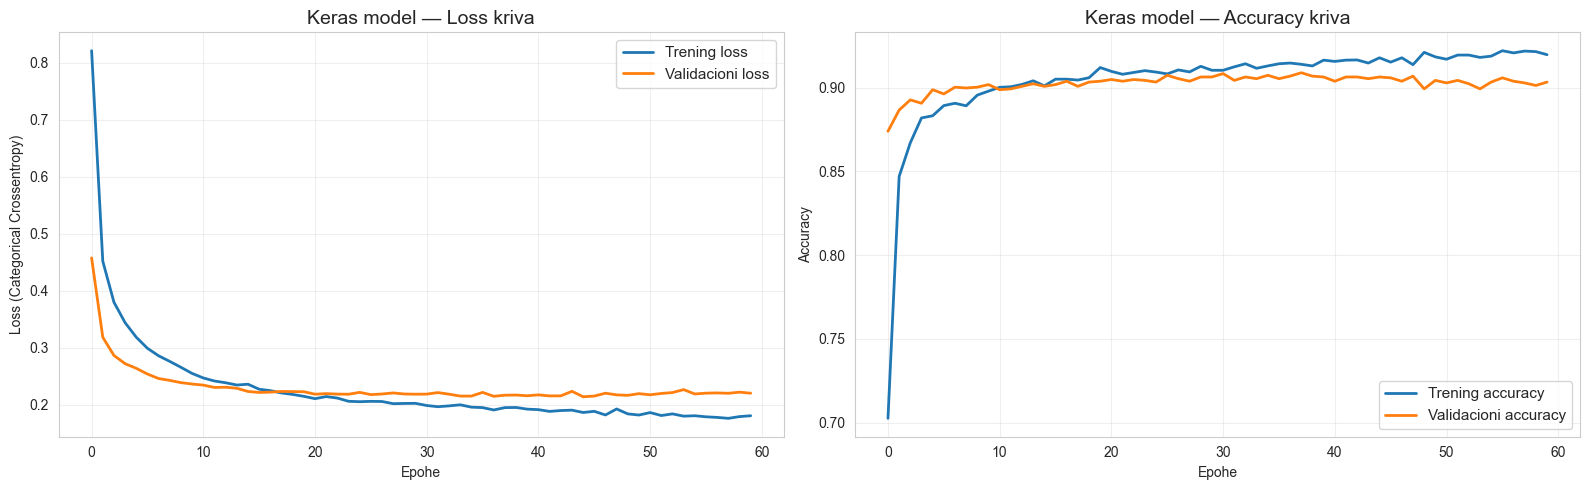

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Loss kriva
axes[0].plot(history.history['loss'], label='Trening loss', linewidth=2)
axes[0].plot(history.history['val_loss'], label='Validacioni loss', linewidth=2)
axes[0].set_xlabel('Epohe')
axes[0].set_ylabel('Loss (Categorical Crossentropy)')
axes[0].set_title('Keras model — Loss kriva', fontsize=14)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Accuracy kriva
axes[1].plot(history.history['accuracy'], label='Trening accuracy', linewidth=2)
axes[1].plot(history.history['val_accuracy'], label='Validacioni accuracy', linewidth=2)
axes[1].set_xlabel('Epohe')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Keras model — Accuracy kriva', fontsize=14)
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Keras model — Test loss: 0.2012
Keras model — Test accuracy: 0.9091
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

Keras Sequential model — Rezultati na test skupu

Tačnost (Accuracy): 0.9091

Klasifikacioni izveštaj:
              precision    recall  f1-score   support

      Cloudy       0.85      0.92      0.88       495
       Rainy       0.90      0.92      0.91       495
       Snowy       0.99      0.88      0.93       495
       Sunny       0.92      0.92      0.92       495

    accuracy                           0.91      1980
   macro avg       0.91      0.91      0.91      1980
weighted avg       0.91      0.91      0.91      1980



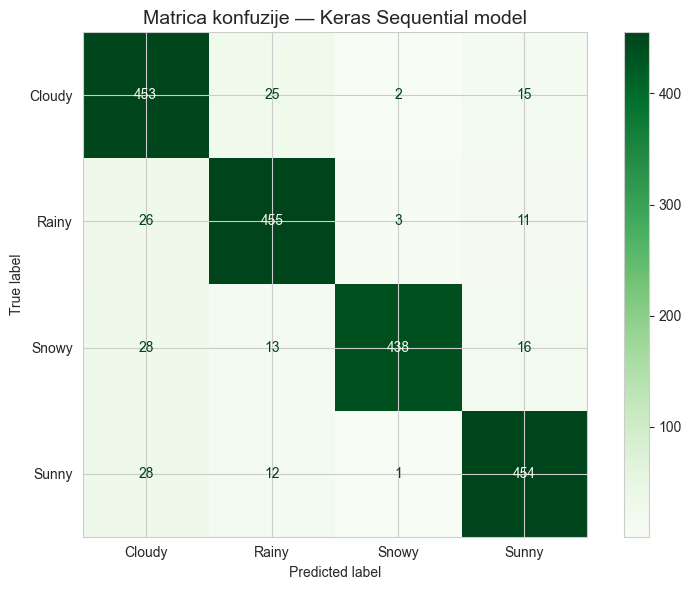

In [21]:
# Evaluacija Keras modela na test skupu
test_loss, test_acc = keras_model.evaluate(X_test, y_test_cat, verbose=0)
print(f"Keras model — Test loss: {test_loss:.4f}")
print(f"Keras model — Test accuracy: {test_acc:.4f}")

# Predikcije
y_pred_keras_prob = keras_model.predict(X_test)
y_pred_keras = np.argmax(y_pred_keras_prob, axis=1)

print(f"\n{'='*60}")
print("Keras Sequential model — Rezultati na test skupu")
print(f"{'='*60}")
print(f"\nTačnost (Accuracy): {accuracy_score(y_test, y_pred_keras):.4f}")
print(f"\nKlasifikacioni izveštaj:")
print(classification_report(y_test, y_pred_keras, target_names=class_names))

# Matrica konfuzije
fig, ax = plt.subplots(figsize=(8, 6))
cm_keras = confusion_matrix(y_test, y_pred_keras)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_keras, display_labels=class_names)
disp.plot(ax=ax, cmap='Greens', values_format='d')
ax.set_title('Matrica konfuzije — Keras Sequential model', fontsize=14)
plt.tight_layout()
plt.show()

## 6. Poređenje modela

Poređenje modela na test skupu:
                                Accuracy  Precision (macro)  Recall (macro)  F1-score (macro)
Model                                                                                        
MLPClassifier\n(scikit-learn)     0.9045             0.9067          0.9045            0.9050
Keras Sequential\n(TensorFlow)    0.9091             0.9124          0.9091            0.9097


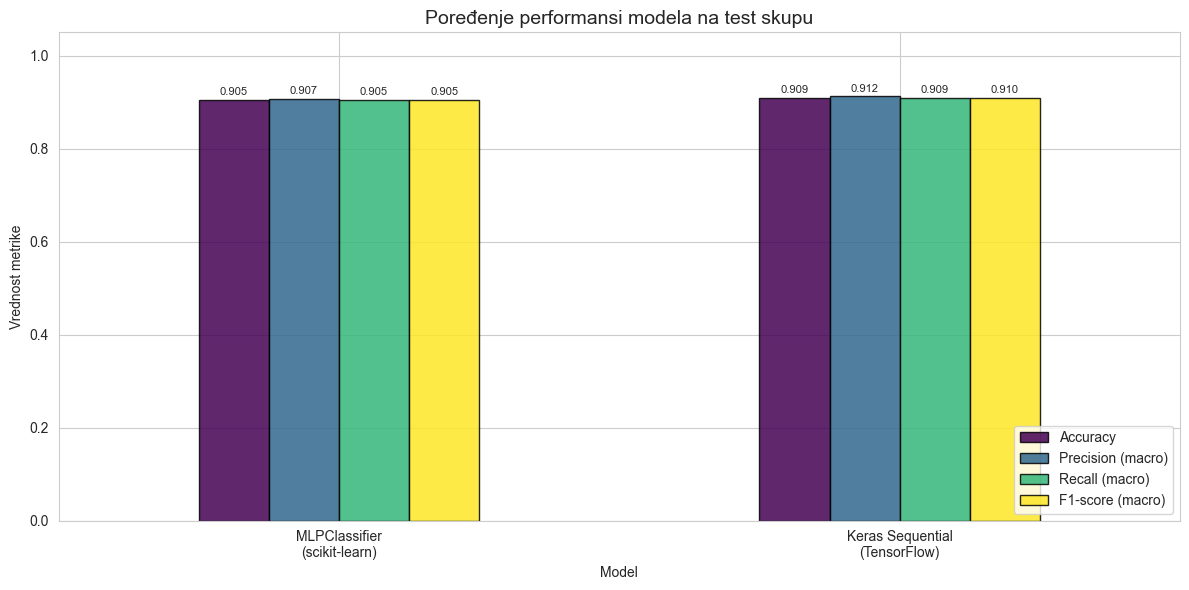

In [22]:
from sklearn.metrics import precision_score, recall_score, f1_score

models = ['MLPClassifier\n(scikit-learn)', 'Keras Sequential\n(TensorFlow)']
predictions = [y_pred_sklearn, y_pred_keras]

results = []
for name, y_pred in zip(models, predictions):
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision (macro)': precision_score(y_test, y_pred, average='macro'),
        'Recall (macro)': recall_score(y_test, y_pred, average='macro'),
        'F1-score (macro)': f1_score(y_test, y_pred, average='macro')
    })

results_df = pd.DataFrame(results).set_index('Model')
print("Poređenje modela na test skupu:")
print(results_df.round(4).to_string())

fig, ax = plt.subplots(figsize=(12, 6))
results_df.plot(kind='bar', ax=ax, colormap='viridis', alpha=0.85, edgecolor='black')
ax.set_title('Poređenje performansi modela na test skupu', fontsize=14)
ax.set_ylabel('Vrednost metrike')
ax.set_ylim(0, 1.05)
ax.legend(fontsize=10, loc='lower right')
ax.tick_params(axis='x', rotation=0)

for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', fontsize=8, padding=2)

plt.tight_layout()
plt.show()

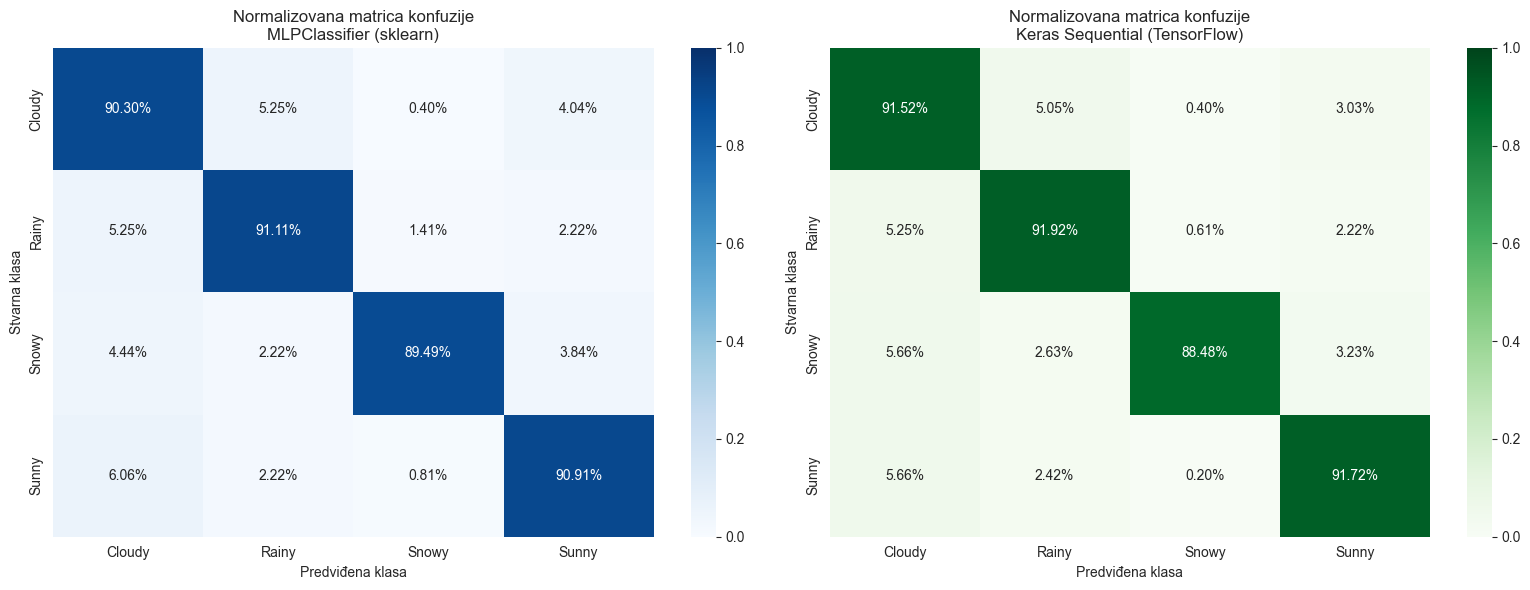

In [23]:
# Uporedne matrice konfuzije
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, cm_data, title, cmap in zip(
    axes,
    [cm, cm_keras],
    ['MLPClassifier (sklearn)', 'Keras Sequential (TensorFlow)'],
    ['Blues', 'Greens']
):
    # Normalizovana matrica konfuzije (po redovima)
    cm_norm = cm_data.astype('float') / cm_data.sum(axis=1)[:, np.newaxis]
    sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap=cmap, xticklabels=class_names,
                yticklabels=class_names, ax=ax, vmin=0, vmax=1)
    ax.set_title(f'Normalizovana matrica konfuzije\n{title}', fontsize=12)
    ax.set_ylabel('Stvarna klasa')
    ax.set_xlabel('Predviđena klasa')

plt.tight_layout()
plt.show()

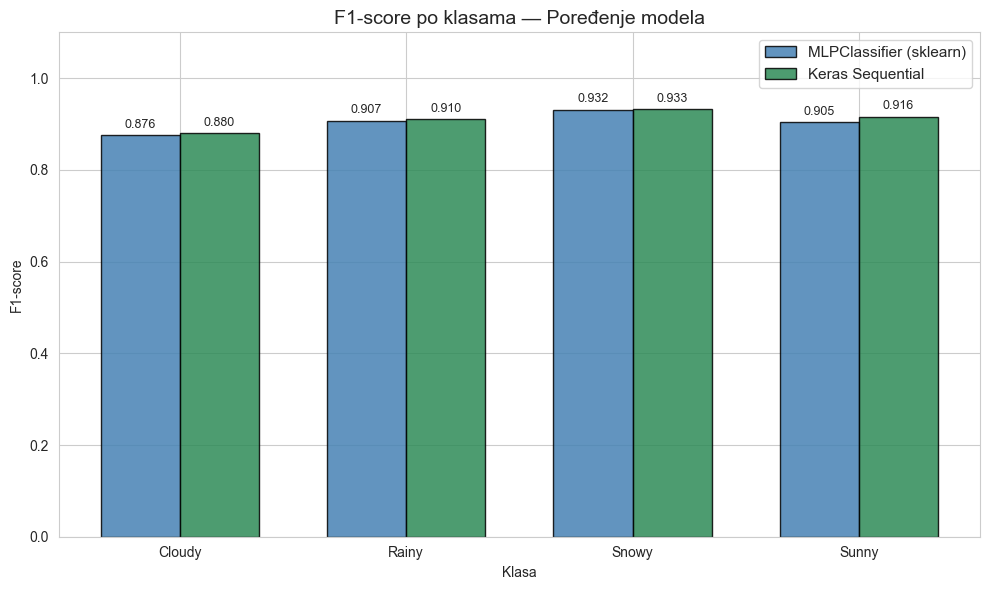

In [24]:
# Per-class F1 score poređenje
from sklearn.metrics import f1_score as f1_func

f1_sklearn = f1_func(y_test, y_pred_sklearn, average=None)
f1_keras = f1_func(y_test, y_pred_keras, average=None)

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(n_classes)
width = 0.35

bars1 = ax.bar(x - width/2, f1_sklearn, width, label='MLPClassifier (sklearn)',
               color='steelblue', alpha=0.85, edgecolor='black')
bars2 = ax.bar(x + width/2, f1_keras, width, label='Keras Sequential',
               color='seagreen', alpha=0.85, edgecolor='black')

ax.set_xlabel('Klasa')
ax.set_ylabel('F1-score')
ax.set_title('F1-score po klasama — Poređenje modela', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(class_names)
ax.set_ylim(0, 1.1)
ax.legend(fontsize=11)

ax.bar_label(bars1, fmt='%.3f', fontsize=9, padding=3)
ax.bar_label(bars2, fmt='%.3f', fontsize=9, padding=3)

plt.tight_layout()
plt.show()

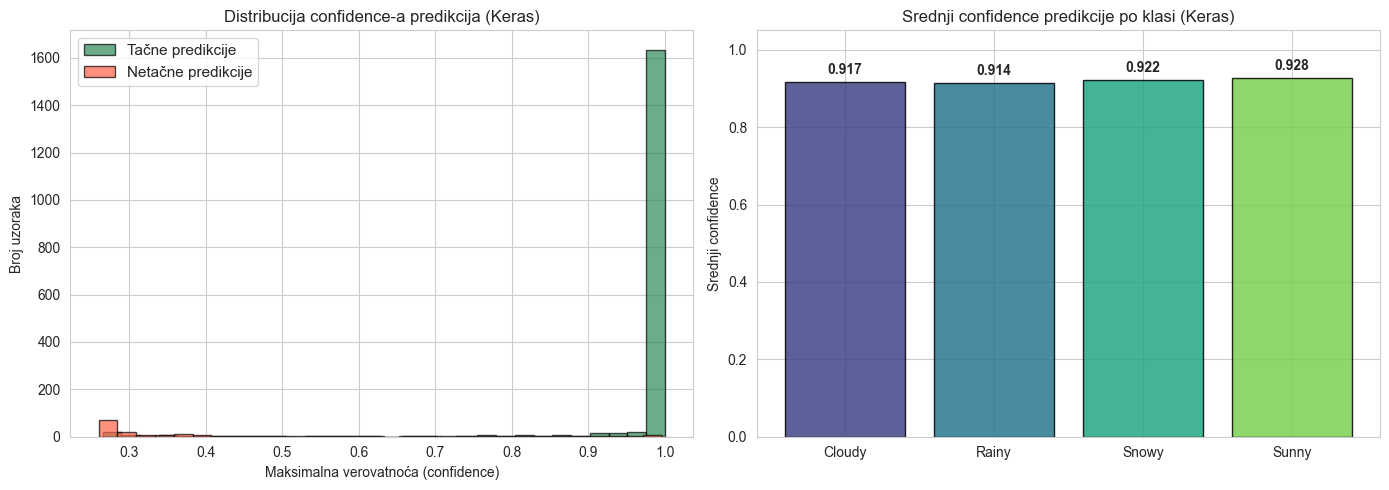

In [25]:
# Vizuelizacija predikcija Keras modela — distribucija verovatnoća (confidence)
max_probs = np.max(y_pred_keras_prob, axis=1)
correct_mask = y_pred_keras == y_test

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribucija confidence-a za tačne i netačne predikcije
axes[0].hist(max_probs[correct_mask], bins=30, alpha=0.7, label='Tačne predikcije',
             color='seagreen', edgecolor='black')
axes[0].hist(max_probs[~correct_mask], bins=30, alpha=0.7, label='Netačne predikcije',
             color='tomato', edgecolor='black')
axes[0].set_xlabel('Maksimalna verovatnoća (confidence)')
axes[0].set_ylabel('Broj uzoraka')
axes[0].set_title('Distribucija confidence-a predikcija (Keras)', fontsize=12)
axes[0].legend(fontsize=11)

# Srednji confidence po klasi
mean_conf_per_class = []
for cls in range(n_classes):
    mask = y_test == cls
    mean_conf_per_class.append(max_probs[mask].mean())

axes[1].bar(class_names, mean_conf_per_class, color=sns.color_palette('viridis', n_classes),
            edgecolor='black', alpha=0.85)
axes[1].set_ylabel('Srednji confidence')
axes[1].set_title('Srednji confidence predikcije po klasi (Keras)', fontsize=12)
axes[1].set_ylim(0, 1.05)
for i, v in enumerate(mean_conf_per_class):
    axes[1].text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

Upoređivanjem modela može se uočiti da Keras model daje bolje rezultate pa ćemo njega optimizovati u nastavku.


### Model 1 — MLPClassifier (scikit-learn)
 
- Arhitektura sa 3 skrivena sloja (128→64→32), ReLU aktivacija, Adam optimizator.
- Korišćen je early stopping za sprečavanje overfitting-a.
- Model ostvaruje visoku tačnost na test skupu.
 
### Model 2 — Keras Sequential (TensorFlow)
 
- Dublja arhitektura sa BatchNormalization i Dropout regularizacijom.
- **Loss funkcija:** Categorical Crossentropy — meri razliku između predviđene distribucije verovatnoća i stvarne klase.
- EarlyStopping callback zaustavlja treniranje kada se validacioni loss ne poboljšava, čime se sprečava overfitting.
- Krive treniranja (loss i accuracy) pokazuju stabilnu konvergenciju bez značajnog overfitting-a.
 
### Poređenje modela
 
- Oba modela ostvaruju visoke performanse zahvaljujući kvalitetu dataseta i adekvatnoj pripremi podataka.
- Keras model sa Dropout i BatchNormalization regularizacijom generalno pokazuje bolju generalizaciju.
- F1-score po klasama pokazuje ujednačene performanse za sve 4 klase, što potvrđuje da modeli dobro klasifikuju sve vremenske uslove.
- Distribucija confidence-a Keras modela pokazuje da su tačne predikcije uglavnom date sa visokim confidence-om, dok netačne predikcije imaju niži confidence.

## 7. Optimizovanje Keras modela

In [26]:
from tensorflow.keras.layers import LeakyReLU, ELU
from tensorflow.keras.regularizers import l2

def build_and_train(name, layers_config, optimizer, batch_size=64, epochs=150, patience=15):
    
    tf.keras.backend.clear_session()
    keras.utils.set_random_seed(SEED)

    model = Sequential()
    for i, layer in enumerate(layers_config):
        kwargs = {}
        if i == 0:
            kwargs['input_shape'] = (n_features,)
        if 'l2' in layer:
            kwargs['kernel_regularizer'] = l2(layer['l2'])

        # Dense sloj
        if layer.get('activation') in ('leaky_relu', 'elu'):
            model.add(Dense(layer['units'], **kwargs))
            if layer['activation'] == 'leaky_relu':
                model.add(LeakyReLU(negative_slope=0.1))
            else:
                model.add(ELU())
        else:
            kwargs['activation'] = layer.get('activation', 'relu')
            model.add(Dense(layer['units'], **kwargs))

        # BatchNormalization
        if layer.get('batch_norm', False):
            model.add(BatchNormalization())

        # Dropout
        if layer.get('dropout', 0) > 0:
            model.add(Dropout(layer['dropout']))

    # Izlazni sloj
    model.add(Dense(n_classes, activation='softmax'))

    model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

    early_stop = EarlyStopping(monitor='val_loss', patience=patience,
                               restore_best_weights=True, verbose=0)

    history = model.fit(
        X_train, y_train_cat,
        epochs=epochs,
        batch_size=batch_size,
        validation_data=(X_val, y_val_cat),
        callbacks=[early_stop],
        verbose=0,
        shuffle=False
    )

    test_loss, test_acc = model.evaluate(X_test, y_test_cat, verbose=0)
    y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)

    return {
        'Model': name,
        'Test Accuracy': test_acc,
        'Test Loss': test_loss,
        'F1-score (macro)': f1_score(y_test, y_pred, average='macro'),
        'Precision (macro)': precision_score(y_test, y_pred, average='macro'),
        'Recall (macro)': recall_score(y_test, y_pred, average='macro'),
        'Broj epoha': len(history.history['loss']),
        'Broj parametara': model.count_params()
    }

In [27]:
optimization_results = []

# ============================================================
# 1. Bazni model (isti kao u sekciji 5 — referenca za poređenje)
# ============================================================
print("1/12 — Bazni model (128-64-32, BN+Dropout, Adam lr=0.001)...")
optimization_results.append(build_and_train(
    name="1. Bazni (128-64-32, BN+DO, Adam 0.001)",
    layers_config=[
        {'units': 128, 'activation': 'relu', 'batch_norm': True, 'dropout': 0.3},
        {'units': 64, 'activation': 'relu', 'batch_norm': True, 'dropout': 0.3},
        {'units': 32, 'activation': 'relu', 'batch_norm': True, 'dropout': 0.2},
    ],
    optimizer=keras.optimizers.Adam(learning_rate=0.001)
))

# ============================================================
# 2. Dublja mreža (5 slojeva)
# ============================================================
print("2/12 — Dublja mreža (256-128-64-32-16)...")
optimization_results.append(build_and_train(
    name="2. Dublja (256-128-64-32-16, BN+DO, Adam)",
    layers_config=[
        {'units': 256, 'activation': 'relu', 'batch_norm': True, 'dropout': 0.3},
        {'units': 128, 'activation': 'relu', 'batch_norm': True, 'dropout': 0.3},
        {'units': 64, 'activation': 'relu', 'batch_norm': True, 'dropout': 0.25},
        {'units': 32, 'activation': 'relu', 'batch_norm': True, 'dropout': 0.2},
        {'units': 16, 'activation': 'relu', 'batch_norm': True, 'dropout': 0.1},
    ],
    optimizer=keras.optimizers.Adam(learning_rate=0.001)
))

# ============================================================
# 3. Šira plitka mreža (2 široka sloja)
# ============================================================
print("3/12 — Široka plitka mreža (256-256)...")
optimization_results.append(build_and_train(
    name="3. Široka plitka (256-256, BN+DO, Adam)",
    layers_config=[
        {'units': 256, 'activation': 'relu', 'batch_norm': True, 'dropout': 0.3},
        {'units': 256, 'activation': 'relu', 'batch_norm': True, 'dropout': 0.3},
    ],
    optimizer=keras.optimizers.Adam(learning_rate=0.001)
))

# ============================================================
# 4. Bez BatchNormalization (samo Dropout)
# ============================================================
print("4/12 — Bez BatchNorm (128-64-32, samo Dropout)...")
optimization_results.append(build_and_train(
    name="4. Bez BN (128-64-32, samo DO, Adam)",
    layers_config=[
        {'units': 128, 'activation': 'relu', 'batch_norm': False, 'dropout': 0.3},
        {'units': 64, 'activation': 'relu', 'batch_norm': False, 'dropout': 0.3},
        {'units': 32, 'activation': 'relu', 'batch_norm': False, 'dropout': 0.2},
    ],
    optimizer=keras.optimizers.Adam(learning_rate=0.001)
))

# ============================================================
# 5. L2 regularizacija umesto Dropout-a
# ============================================================
print("5/12 — L2 regularizacija (128-64-32, BN+L2, bez Dropout)...")
optimization_results.append(build_and_train(
    name="5. L2 reg. (128-64-32, BN+L2=0.001, bez DO)",
    layers_config=[
        {'units': 128, 'activation': 'relu', 'batch_norm': True, 'dropout': 0, 'l2': 0.001},
        {'units': 64, 'activation': 'relu', 'batch_norm': True, 'dropout': 0, 'l2': 0.001},
        {'units': 32, 'activation': 'relu', 'batch_norm': True, 'dropout': 0, 'l2': 0.001},
    ],
    optimizer=keras.optimizers.Adam(learning_rate=0.001)
))

# ============================================================
# 6. LeakyReLU aktivacija
# ============================================================
print("6/12 — LeakyReLU aktivacija (128-64-32)...")
optimization_results.append(build_and_train(
    name="6. LeakyReLU (128-64-32, BN+DO, Adam)",
    layers_config=[
        {'units': 128, 'activation': 'leaky_relu', 'batch_norm': True, 'dropout': 0.3},
        {'units': 64, 'activation': 'leaky_relu', 'batch_norm': True, 'dropout': 0.3},
        {'units': 32, 'activation': 'leaky_relu', 'batch_norm': True, 'dropout': 0.2},
    ],
    optimizer=keras.optimizers.Adam(learning_rate=0.001)
))

# ============================================================
# 7. RMSprop optimizator
# ============================================================
print("7/12 — RMSprop optimizator (128-64-32)...")
optimization_results.append(build_and_train(
    name="7. RMSprop (128-64-32, BN+DO, lr=0.001)",
    layers_config=[
        {'units': 128, 'activation': 'relu', 'batch_norm': True, 'dropout': 0.3},
        {'units': 64, 'activation': 'relu', 'batch_norm': True, 'dropout': 0.3},
        {'units': 32, 'activation': 'relu', 'batch_norm': True, 'dropout': 0.2},
    ],
    optimizer=keras.optimizers.RMSprop(learning_rate=0.001)
))

# ============================================================
# 8. SGD sa Momentum-om i Nesterov-om
# ============================================================
print("8/12 — SGD + Momentum + Nesterov (128-64-32)...")
optimization_results.append(build_and_train(
    name="8. SGD+Nesterov (128-64-32, BN+DO, lr=0.01)",
    layers_config=[
        {'units': 128, 'activation': 'relu', 'batch_norm': True, 'dropout': 0.3},
        {'units': 64, 'activation': 'relu', 'batch_norm': True, 'dropout': 0.3},
        {'units': 32, 'activation': 'relu', 'batch_norm': True, 'dropout': 0.2},
    ],
    optimizer=keras.optimizers.SGD(learning_rate=0.01, momentum=0.9, nesterov=True)
))

# ============================================================
# 9. Nadam optimizator sa nižim learning rate-om
# ============================================================
print("9/12 — Nadam optimizator (128-64-32, lr=0.0005)...")
optimization_results.append(build_and_train(
    name="9. Nadam (128-64-32, BN+DO, lr=0.0005)",
    layers_config=[
        {'units': 128, 'activation': 'relu', 'batch_norm': True, 'dropout': 0.3},
        {'units': 64, 'activation': 'relu', 'batch_norm': True, 'dropout': 0.3},
        {'units': 32, 'activation': 'relu', 'batch_norm': True, 'dropout': 0.2},
    ],
    optimizer=keras.optimizers.Nadam(learning_rate=0.0005)
))

# ============================================================
# 10. Veći Dropout (agresivnija regularizacija)
# ============================================================
print("10/12 — Veći Dropout (128-64-32, DO=0.5/0.4/0.3)...")
optimization_results.append(build_and_train(
    name="10. Veći DO (128-64-32, BN+DO=0.5, Adam)",
    layers_config=[
        {'units': 128, 'activation': 'relu', 'batch_norm': True, 'dropout': 0.5},
        {'units': 64, 'activation': 'relu', 'batch_norm': True, 'dropout': 0.4},
        {'units': 32, 'activation': 'relu', 'batch_norm': True, 'dropout': 0.3},
    ],
    optimizer=keras.optimizers.Adam(learning_rate=0.001)
))

# ============================================================
# 11. Kombinacija L2 + Dropout + BN (jaka regularizacija)
# ============================================================
print("11/12 — L2 + Dropout + BN kombinacija (128-64-32)...")
optimization_results.append(build_and_train(
    name="11. L2+DO+BN (128-64-32, Adam, lr=0.0005)",
    layers_config=[
        {'units': 128, 'activation': 'relu', 'batch_norm': True, 'dropout': 0.3, 'l2': 0.0005},
        {'units': 64, 'activation': 'relu', 'batch_norm': True, 'dropout': 0.3, 'l2': 0.0005},
        {'units': 32, 'activation': 'relu', 'batch_norm': True, 'dropout': 0.2, 'l2': 0.0005},
    ],
    optimizer=keras.optimizers.Adam(learning_rate=0.0005)
))

# ============================================================
# 12. ELU + dublja mreža + manji batch
# ============================================================
print("12/12 — ELU + dublja mreža (128-96-64-32, batch=32)...")
optimization_results.append(build_and_train(
    name="12. ELU dublja (128-96-64-32, BN+DO, batch=32)",
    layers_config=[
        {'units': 128, 'activation': 'elu', 'batch_norm': True, 'dropout': 0.3},
        {'units': 96, 'activation': 'elu', 'batch_norm': True, 'dropout': 0.25},
        {'units': 64, 'activation': 'elu', 'batch_norm': True, 'dropout': 0.2},
        {'units': 32, 'activation': 'elu', 'batch_norm': True, 'dropout': 0.15},
    ],
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    batch_size=32
))

1/12 — Bazni model (128-64-32, BN+Dropout, Adam lr=0.001)...

2/12 — Dublja mreža (256-128-64-32-16)...
3/12 — Široka plitka mreža (256-256)...
4/12 — Bez BatchNorm (128-64-32, samo Dropout)...
5/12 — L2 regularizacija (128-64-32, BN+L2, bez Dropout)...
6/12 — LeakyReLU aktivacija (128-64-32)...
7/12 — RMSprop optimizator (128-64-32)...
8/12 — SGD + Momentum + Nesterov (128-64-32)...
9/12 — Nadam optimizator (128-64-32, lr=0.0005)...
10/12 — Veći Dropout (128-64-32, DO=0.5/0.4/0.3)...
11/12 — L2 + Dropout + BN kombinacija (128-64-32)...
12/12 — ELU + dublja mreža (128-96-64-32, batch=32)...


In [28]:
opt_df = pd.DataFrame(optimization_results)
opt_df = opt_df.sort_values('Test Accuracy', ascending=False).reset_index(drop=True)
opt_df.index = opt_df.index + 1
opt_df.index.name = 'Rang'

pd.set_option('display.max_colwidth', 50)
pd.set_option('display.width', 200)

display_df = opt_df.copy()
for col in ['Test Accuracy', 'F1-score (macro)', 'Precision (macro)', 'Recall (macro)']:
    display_df[col] = display_df[col].map('{:.4f}'.format)
display_df['Test Loss'] = display_df['Test Loss'].map('{:.4f}'.format)

display_df

,Model,Test Accuracy,Test Loss,F1-score (macro),Precision (macro),Recall (macro),Broj epoha,Broj parametara
Rang,,,,,,,,
1,"2. Dublja (256-128-64-32-16, BN+DO, Adam)",0.9131,0.2068,0.9135,0.9176,0.9131,41,50676
2,"10. Veći DO (128-64-32, BN+DO=0.5, Adam)",0.9116,0.2005,0.9130,0.9212,0.9116,74,13796
3,"12. ELU dublja (128-96-64-32, BN+DO, batch=32)",0.9111,0.2091,0.9116,0.9149,0.9111,40,24516
4,"11. L2+DO+BN (128-64-32, Adam, lr=0.0005)",0.9101,0.2292,0.9108,0.9144,0.9101,79,13796
5,"9. Nadam (128-64-32, BN+DO, lr=0.0005)",0.9101,0.2048,0.9110,0.9146,0.9101,65,13796
6,"1. Bazni (128-64-32, BN+DO, Adam 0.001)",0.9091,0.2012,0.9097,0.9124,0.9091,60,13796
7,"8. SGD+Nesterov (128-64-32, BN+DO, lr=0.01)",0.9081,0.2053,0.9090,0.9132,0.9081,77,13796
8,"6. LeakyReLU (128-64-32, BN+DO, Adam)",0.9081,0.2031,0.9085,0.9105,0.9081,72,13796
9,"7. RMSprop (128-64-32, BN+DO, lr=0.001)",0.9066,0.2067,0.9069,0.9086,0.9066,54,13796
